# Project setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

while not (PROJECT_ROOT / "shared" / "config.py").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not locate project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/sanjeet/ai_workspace/KWS model/sih-2026


# Load configuration

In [2]:
from shared.config import KEYWORD, MODELS_DIR
from shared.feature_spec import SPEC, FEATURE_SHAPE
from training.model import N_CLASSES

print(f"Keyword       : {KEYWORD}")
print(f"Feature shape : {FEATURE_SHAPE}")
print(f"Classes       : {N_CLASSES}")

I0000 00:00:1789840245.927289  165425 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Keyword       : marvin
Feature shape : (49, 20, 1)
Classes       : 3


# Locate the trained model

In [26]:
model_path = MODELS_DIR / f"{KEYWORD}.fp16.tflite"

if not model_path.exists():
    raise FileNotFoundError(model_path)

print(f"Using model: {model_path}")
print(type(model_path))

Using model: /home/sanjeet/ai_workspace/KWS model/sih-2026/models/marvin.fp16.tflite
<class 'pathlib.PosixPath'>


# Load model

In [27]:
interpreter = tf.lite.Interpreter(
    model_path=str(model_path)
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input dtype :", input_details[0]["dtype"])
print("Output dtype:", output_details[0]["dtype"])

Input dtype : <class 'numpy.float32'>
Output dtype: <class 'numpy.float32'>


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


# Load current validation set

In [17]:
from training.train import collect

train_data, val_data, speakers, gsc_split = collect(
    KEYWORD,
    holdout_speaker=None,
    noise_cap=400,
)

x_val, y_val, _ = val_data.arrays()

print(f"Validation samples : {len(x_val)}")
print(f"Feature shape      : {x_val.shape[1:]}")
print(f"Using GSC test split: {gsc_split}")

  loaded 2000 clips...
  loaded 3000 clips...
  loaded 4000 clips...
  loaded 6000 clips...
  loaded 7000 clips...
  loaded 8000 clips...
  loaded 9000 clips...
  loaded 10000 clips...
  loaded 11000 clips...
  loaded 12000 clips...
  loaded 13000 clips...
  loaded 14000 clips...
  loaded 15000 clips...
  loaded 16000 clips...
  loaded 17000 clips...
  loaded 18000 clips...
  loaded 19000 clips...
  loaded 20000 clips...
  loaded 21000 clips...
  loaded 22000 clips...
  loaded 23000 clips...
Validation samples : 11164
Feature shape      : (49, 20, 1)
Using GSC test split: True


# Run inference

In [ ]:
import numpy as np

input_info = input_details[0]
output_info = output_details[0]

probs = np.zeros((len(x_val), 3), dtype=np.float32)

for i, x in enumerate(x_val):
    x = x[np.newaxis, ...].astype(input_info["dtype"])

    interpreter.set_tensor(
        input_info["index"],
        x
    )

    interpreter.invoke()

    probs[i] = interpreter.get_tensor(
        output_info["index"]
    )[0]

print("Predictions shape:", probs.shape)
y_pred = probs.argmax(axis=1)

print("Predictions shape:", probs.shape)
print("Predicted labels shape:", y_pred.shape)

# Confusion Matrix

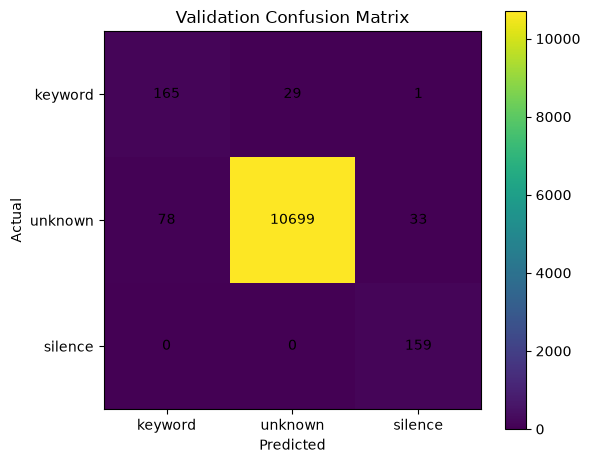

[[  165    29     1]
 [   78 10699    33]
 [    0     0   159]]


In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

CLASS_NAMES = ["keyword", "unknown", "silence"]

cm = confusion_matrix(
    y_val,
    y_pred,
    labels=[0, 1, 2],
)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm)

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Validation Confusion Matrix")

for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print(cm)

# TPR / FAR at current threshold

In [36]:
from training.train import wake_metrics, WAKE_SCORE_THRESHOLD

threshold = WAKE_SCORE_THRESHOLD

metrics = wake_metrics(
    probs,
    y_val,
    threshold,
)

print(f"Threshold     : {metrics['threshold']:.2f}")
print(f"TPR           : {metrics['tpr']:.4f} ({metrics['tpr']*100:.2f}%)")
print(f"FAR           : {metrics['far']:.4f} ({metrics['far']*100:.2f}%)")
print(f"False accepts : {metrics['false_accepts']}")
print(f"Keywords      : {metrics['n_keyword']}")
print(f"Negatives     : {metrics['n_negative']}")
print(f"FAR by class  : {metrics['far_by_class']}")

Threshold     : 0.52
TPR           : 0.8410 (84.10%)
FAR           : 0.0055 (0.55%)
False accepts : 60
Keywords      : 195
Negatives     : 10969
FAR by class  : {'unknown': 0.0056, 'silence': 0.0}


# Threshold Sweep

In [37]:
import numpy as np

thresholds = np.arange(0.30, 0.96, 0.05)

sweep = []

for threshold in thresholds:
    m = wake_metrics(probs, y_val, float(threshold))
    sweep.append({
        "threshold": threshold,
        "TPR": m["tpr"],
        "FAR": m["far"],
        "false_accepts": m["false_accepts"],
    })

for row in sweep:
    print(
        f"Threshold={row['threshold']:.2f}  "
        f"TPR={row['TPR']:.4f}  "
        f"FAR={row['FAR']:.4f}  "
        f"False accepts={row['false_accepts']}"
    )

Threshold=0.30  TPR=0.8667  FAR=0.0095  False accepts=104
Threshold=0.35  TPR=0.8667  FAR=0.0077  False accepts=85
Threshold=0.40  TPR=0.8667  FAR=0.0067  False accepts=74
Threshold=0.45  TPR=0.8564  FAR=0.0065  False accepts=71
Threshold=0.50  TPR=0.8462  FAR=0.0060  False accepts=66
Threshold=0.55  TPR=0.8256  FAR=0.0051  False accepts=56
Threshold=0.60  TPR=0.8154  FAR=0.0047  False accepts=52
Threshold=0.65  TPR=0.8103  FAR=0.0041  False accepts=45
Threshold=0.70  TPR=0.7949  FAR=0.0035  False accepts=38
Threshold=0.75  TPR=0.7897  FAR=0.0027  False accepts=30
Threshold=0.80  TPR=0.7436  FAR=0.0026  False accepts=28
Threshold=0.85  TPR=0.7282  FAR=0.0018  False accepts=20
Threshold=0.90  TPR=0.7077  FAR=0.0009  False accepts=10
Threshold=0.95  TPR=0.6769  FAR=0.0005  False accepts=6


# Plot threshold trade-off

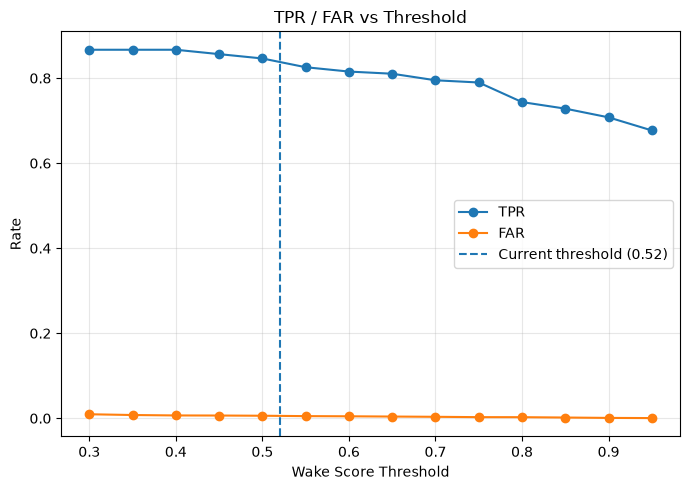

In [38]:
thresholds_plot = [r["threshold"] for r in sweep]
tpr_plot = [r["TPR"] for r in sweep]
far_plot = [r["FAR"] for r in sweep]

plt.figure(figsize=(7, 5))

plt.plot(thresholds_plot, tpr_plot, marker="o", label="TPR")
plt.plot(thresholds_plot, far_plot, marker="o", label="FAR")

plt.axvline(
    WAKE_SCORE_THRESHOLD,
    linestyle="--",
    label=f"Current threshold ({WAKE_SCORE_THRESHOLD:.2f})",
)

plt.xlabel("Wake Score Threshold")
plt.ylabel("Rate")
plt.title("TPR / FAR vs Threshold")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Final validation metrics

In [39]:
from sklearn.metrics import accuracy_score

final_metrics = {
    "accuracy": accuracy_score(y_val, y_pred),
    "tpr": metrics["tpr"],
    "far": metrics["far"],
    "false_accepts": metrics["false_accepts"],
    "threshold": metrics["threshold"],
}

print("=== Final Validation Metrics ===")
print(f"Accuracy       : {final_metrics['accuracy']:.4f}")
print(f"TPR            : {final_metrics['tpr']:.4f}")
print(f"FAR            : {final_metrics['far']:.4f}")
print(f"False accepts  : {final_metrics['false_accepts']}")
print(f"Threshold      : {final_metrics['threshold']:.2f}")

=== Final Validation Metrics ===
Accuracy       : 0.9874
TPR            : 0.8410
FAR            : 0.0055
False accepts  : 60
Threshold      : 0.52


INFO:tensorflow:Assets written to: /tmp/tmp1b4wdu9c/assets


INFO:tensorflow:Assets written to: /tmp/tmp1b4wdu9c/assets


Saved artifact at '/tmp/tmp1b4wdu9c'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 49, 20, 1), dtype=tf.float32, name='mfcc')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  127813063909712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127813063914128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127813063915088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127813063914704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127813063914896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127813063912400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127813063914512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127813063914320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127813063910672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127813063916048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127813063915472: TensorS

W0000 00:00:1789842861.850941  165425 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1789842861.851013  165425 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1789842861.851706  165425 reader.cc:83] Reading SavedModel from: /tmp/tmp1b4wdu9c
I0000 00:00:1789842861.854923  165425 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1789842861.854966  165425 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp1b4wdu9c
I0000 00:00:1789842861.887451  165425 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1789842862.033836  165425 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp1b4wdu9c
I0000 00:00:1789842862.075946  165425 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 224270 microseconds.


INFO:tensorflow:Assets written to: /tmp/tmp9a1lgqhu/assets


INFO:tensorflow:Assets written to: /tmp/tmp9a1lgqhu/assets


Saved artifact at '/tmp/tmp9a1lgqhu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 49, 20, 1), dtype=tf.float32, name='mfcc')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  127815071620880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127815071620304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127815071616080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127815071617040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127815071619728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127815071618384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127815071618192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127815071620496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127815071618576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127815071613968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127815071618768: TensorS

/home/sanjeet/ai_workspace/KWS model/sih-2026/.venv/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1789842864.114820  165425 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1789842864.114881  165425 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1789842864.115083  165425 reader.cc:83] Reading SavedModel from: /tmp/tmp9a1lgqhu
I0000 00:00:1789842864.117886  165425 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1789842864.117955  165425 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp9a1lgqhu
I0000 00:00:1789842864.146826  165425 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1789842864.282735  165425 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp9a1lgqhu
I0000 00:00:1789842864.327849  165425 loader.cc:471] 

FP16: /home/sanjeet/ai_workspace/KWS model/sih-2026/models/marvin.fp16.tflite — 59,072 bytes
INT8: /home/sanjeet/ai_workspace/KWS model/sih-2026/models/marvin.int8.tflite — 48,888 bytes


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1789842865.463004  165425 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This will be generated by the exporter.
